In [ ]:
!pip install -q datasets pillow matplotlib

import os
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset


In [ ]:
# Load the full dataset (train + test)
dataset = load_dataset("zhimeng/hico_det")
print(dataset)

test_ds = dataset["test"]
len(test_ds)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00013.parquet:   0%|          | 0.00/497M [00:00<?, ?B/s]

data/train-00001-of-00013.parquet:   0%|          | 0.00/509M [00:00<?, ?B/s]

data/train-00002-of-00013.parquet:   0%|          | 0.00/493M [00:00<?, ?B/s]

...

data/test-00003-of-00004.parquet:   0%|          | 0.00/421M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/38118 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9658 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'size', 'objects', 'positive_captions', 'negative_captions', 'ambiguous_captions', 'positive_objects', 'negative_objects', 'ambiguous_objects'],
        num_rows: 38118
    })
    test: Dataset({
        features: ['image', 'size', 'objects', 'positive_captions', 'negative_captions', 'ambiguous_captions', 'positive_objects', 'negative_objects', 'ambiguous_objects'],
        num_rows: 9658
    })
})


9658

In [ ]:
sample = test_ds[0]
sample.keys()


dict_keys(['image', 'size', 'objects', 'positive_captions', 'negative_captions', 'ambiguous_captions', 'positive_objects', 'negative_objects', 'ambiguous_objects'])

In [ ]:
print("Image type:", type(sample["image"]))
print("Positive captions:", sample["positive_captions"])
print("Negative captions:", sample["negative_captions"])
print("Ambiguous captions:", sample["ambiguous_captions"])
print("Objects:", sample["objects"])  # usually like [("bicycle", "ride"), ...]


Image type: <class 'PIL.Image.Image'>
Positive captions: [('bench', 'sit_on')]
Negative captions: [('bench', 'inspect'), ('bench', 'lie_on'), ('bench', 'no_interaction')]
Ambiguous captions: []
Objects: [{'id': 246, 'bbox_human': [320, 359, 306, 349], 'bbox_object': [148, 376, 345, 414], 'connection': 1, 'invis': 0}]


In [ ]:
def show_sample(idx, ds=test_ds):
    sample = ds[idx]
    img = sample["image"]

    print(f"Index: {idx}")
    print("Positive HOIs (ground truth):")
    for cap in sample["positive_captions"]:
        print("  -", cap)

    print("\nNegative HOIs:")
    for cap in sample["negative_captions"][:5]:
        print("  -", cap)
    if len(sample["negative_captions"]) > 5:
        print("  ...")

    # Show the image
    plt.imshow(img)
    plt.axis("off")
    plt.show()


In [ ]:
import random

random.seed(123)
N_IMAGES = 20

all_indices = list(range(len(test_ds)))
random.shuffle(all_indices)

test_indices = all_indices[:N_IMAGES]
test_indices


[4823,
 8829,
 6853,
 2516,
 1312,
 2553,
 8236,
 4884,
 9516,
 6306,
 1770,
 6387,
 5393,
 1785,
 3493,
 6770,
 7666,
 4645,
 1789,
 9567]

In [ ]:
out_dir = Path("hoi_test_images")
out_dir.mkdir(exist_ok=True)

def save_selected_images(indices, ds=test_ds, out_dir=out_dir):
    records = []
    for idx in indices:
        sample = ds[idx]
        img = sample["image"]
        filename = f"img_{idx:05d}.jpg"
        filepath = out_dir / filename
        img.save(filepath)

        records.append({
            "idx": idx,
            "filename": str(filepath),
            "positive_captions": sample["positive_captions"],
            "objects": sample["objects"],
        })
    return records

records = save_selected_images(test_indices)
len(records), records[:2]


(20,
 [{'idx': 4823,
   'filename': 'hoi_test_images/img_04823.jpg',
   'positive_captions': "[('person', 'no_interaction')]",
   'objects': "[{'id': 170, 'bbox_human': [295, 640, 2, 427], 'bbox_object': [110, 326, 114, 426], 'connection': 1, 'invis': 0}]"},
  {'idx': 8829,
   'filename': 'hoi_test_images/img_08829.jpg',
   'positive_captions': "[('bottle', 'drink_with'), ('bottle', 'hold')]",
   'objects': "[{'id': 48, 'bbox_human': [43, 618, 58, 474], 'bbox_object': [188, 501, 168, 366], 'connection': 1, 'invis': 0}, {'id': 49, 'bbox_human': [45, 623, 73, 470], 'bbox_object': [197, 506, 172, 360], 'connection': 1, 'invis': 0}]"}])

In [ ]:
len(records), records[:3]


(20,
 [{'idx': 4823,
   'filename': 'hoi_test_images/img_04823.jpg',
   'positive_captions': "[('person', 'no_interaction')]",
   'objects': "[{'id': 170, 'bbox_human': [295, 640, 2, 427], 'bbox_object': [110, 326, 114, 426], 'connection': 1, 'invis': 0}]"},
  {'idx': 8829,
   'filename': 'hoi_test_images/img_08829.jpg',
   'positive_captions': "[('bottle', 'drink_with'), ('bottle', 'hold')]",
   'objects': "[{'id': 48, 'bbox_human': [43, 618, 58, 474], 'bbox_object': [188, 501, 168, 366], 'connection': 1, 'invis': 0}, {'id': 49, 'bbox_human': [45, 623, 73, 470], 'bbox_object': [197, 506, 172, 360], 'connection': 1, 'invis': 0}]"},
  {'idx': 6853,
   'filename': 'hoi_test_images/img_06853.jpg',
   'positive_captions': "[('dog', 'hold'), ('dog', 'hug'), ('dog', 'scratch')]",
   'objects': "[{'id': 116, 'bbox_human': [25, 378, 94, 418], 'bbox_object': [217, 611, 22, 335], 'connection': 1, 'invis': 0}, {'id': 118, 'bbox_human': [3, 636, 2, 475], 'bbox_object': [7, 618, 98, 458], 'connecti

In [ ]:
import matplotlib.pyplot as plt

def show_record(rec):
    idx = rec["idx"]
    sample = test_ds[idx]
    img = sample["image"]

    print(f"Index: {idx}")

    gt_raw = sample["positive_captions"]
    gt_list = parse_positive_captions(gt_raw)

    print("Positive HOIs (GT):")
    for cap in gt_list:
        print("  -", cap)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    return gt_list


In [ ]:
import ast

def parse_positive_captions(raw):
    """
    Convert the raw 'positive_captions' field into a list of strings like
    'person no_interaction', 'bicycle ride', etc.
    """
    # Case 1: already a list -> just format tuples
    if isinstance(raw, list):
        caps = []
        for x in raw:
            if isinstance(x, (list, tuple)) and len(x) == 2:
                caps.append(f"{x[0]} {x[1]}")
            else:
                caps.append(str(x))
        return caps

    # Case 2: it's a string representation like "[('person','no_interaction')]"
    if isinstance(raw, str):
        try:
            obj = ast.literal_eval(raw)   # safely parse the string to Python object
            return parse_positive_captions(obj)  # recurse to Case 1
        except Exception:
            # If parsing fails, just return the whole string as one caption
            return [raw]

    # Fallback
    return [str(raw)]


Index: 4823
Positive HOIs (GT):
  - person no_interaction


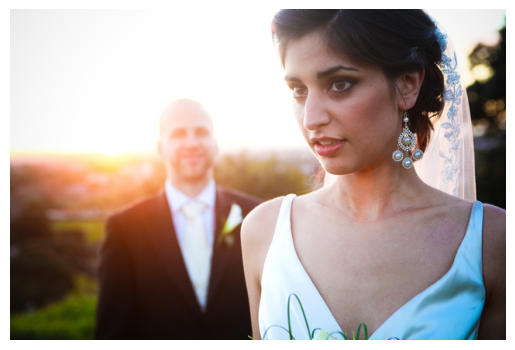

Index: 8829
Positive HOIs (GT):
  - bottle drink_with
  - bottle hold


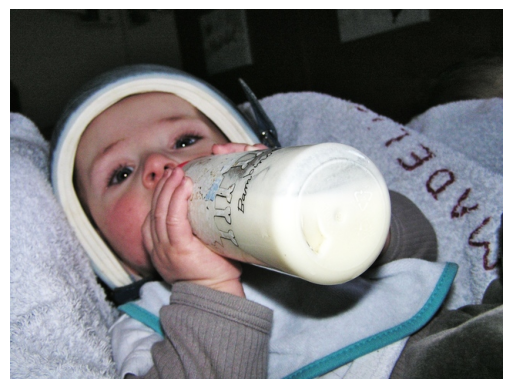

Index: 6853
Positive HOIs (GT):
  - dog hold
  - dog hug
  - dog scratch


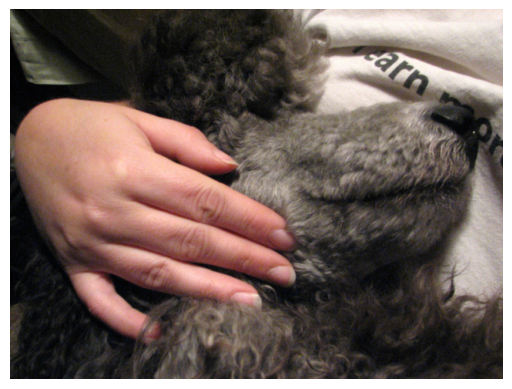

In [ ]:
for r in records[:3]:
    show_record(r)


In [ ]:
for i, r in enumerate(records):
    print(i, r["filename"])


0 hoi_test_images/img_04823.jpg
1 hoi_test_images/img_08829.jpg
2 hoi_test_images/img_06853.jpg
3 hoi_test_images/img_02516.jpg
4 hoi_test_images/img_01312.jpg
5 hoi_test_images/img_02553.jpg
6 hoi_test_images/img_08236.jpg
7 hoi_test_images/img_04884.jpg
8 hoi_test_images/img_09516.jpg
9 hoi_test_images/img_06306.jpg
10 hoi_test_images/img_01770.jpg
11 hoi_test_images/img_06387.jpg
12 hoi_test_images/img_05393.jpg
13 hoi_test_images/img_01785.jpg
14 hoi_test_images/img_03493.jpg
15 hoi_test_images/img_06770.jpg
16 hoi_test_images/img_07666.jpg
17 hoi_test_images/img_04645.jpg
18 hoi_test_images/img_01789.jpg
19 hoi_test_images/img_09567.jpg


In [ ]:
vlm_results = []

def add_vlm_result(record_idx_in_list, vlm_predictions):
    rec = records[record_idx_in_list]
    sample = test_ds[rec["idx"]]

    gt_list = parse_positive_captions(sample["positive_captions"])

    entry = {
        "idx": rec["idx"],
        "filename": rec["filename"],
        "gt_hois": gt_list,                  # ✅ normalized list of strings
        "vlm_hois_zero_shot": vlm_predictions,
    }
    vlm_results.append(entry)
    return entry


In [ ]:
entry_14= add_vlm_result(
    14,   # because img_09516.jpg was records[0]
    [
        "<wear glasses> <wear shirt> <wear pants> <wear lanyard> <hold marker> <wear sunglasses> <wear top> <wear skirt> <wear earrings> <touch table>"
    ]
)


In [ ]:
def evaluate_entry(entry):
    gt = set(entry["gt_hois"])              # already list of strings like "person no_interaction"

    vlm_pairs = []
    for s in entry["vlm_hois_zero_shot"]:
        s = s.strip("<> \n")
        parts = s.split()
        if len(parts) >= 2:
            verb = parts[0]
            obj = " ".join(parts[1:])
            # store as "object verb" to roughly match GT format
            vlm_pairs.append(f"{obj} {verb}")
    vlm = set(vlm_pairs)

    correct = gt & vlm
    missed = gt - vlm
    extra  = vlm - gt

    return {
        "correct": list(correct),
        "missed": list(missed),
        "extra": list(extra),
    }


In [ ]:
import matplotlib.pyplot as plt

def show_image_and_analysis(entry):
    sample = test_ds[entry["idx"]]
    img = sample["image"]

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Ground-Truth HOIs (positive_captions):")
    for h in entry["gt_hois"]:
        print("  -", h)

    print("\nGemini HOIs (zero-shot):")
    for h in entry["vlm_hois_zero_shot"]:
        print("  -", h)

    eval_res = evaluate_entry(entry)
    print("\nCorrect:", eval_res["correct"])
    print("Missed:", eval_res["missed"])
    print("Extra:", eval_res["extra"])


Index: 3493
Positive HOIs (GT):
  - wine_glass hold


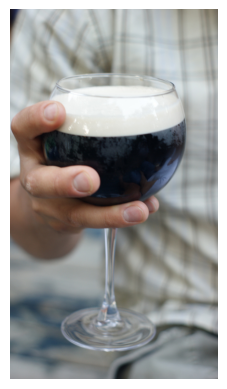

{'correct': [],
 'missed': ['wine_glass hold'],
 'extra': ['glasses> <wear shirt> <wear pants> <wear lanyard> <hold marker> <wear sunglasses> <wear top> <wear skirt> <wear earrings> <touch table wear']}

In [ ]:
show_record(records[14])        # just to check GT printing
evaluate_entry(entry_14)        # see correct/missed/extra




In [ ]:
sample = test_ds[records[14]["idx"]]
print("Raw positive_captions:", sample["positive_captions"])
print("Type:", type(sample["positive_captions"]))


Raw positive_captions: [('wine_glass', 'hold')]
Type: <class 'str'>
